# S06: One sided derivatives. Higher order Derivatives. Derivation Rules.

In [23]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from IPython.display import Math, display
from sympy import Function, diff, Symbol, latex


# One sided derivatives


 ## Example: absolute value

 We use sympy to define the absolute value function:
 $$f(x) = |x|$$

In [24]:
# Define a symbol x assuming it is real valued
x = sy.Symbol('x', real=True)




In [25]:
f = sy.Abs(x)
display(Math(f"f(x) = {sy.latex(f)}"))

<IPython.core.display.Math object>

And we plot the function:

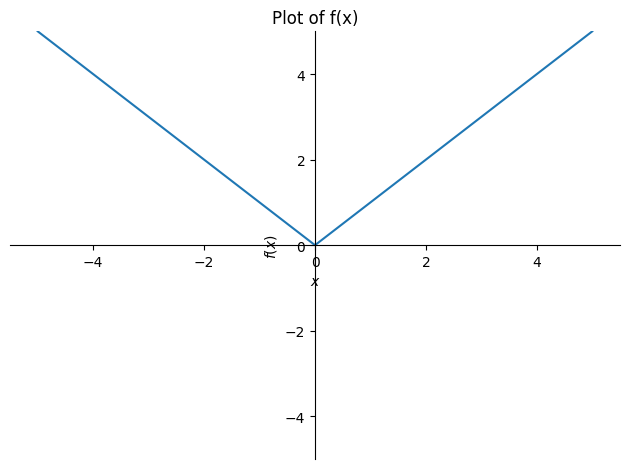

In [26]:
sy.plot(f, (x, -5, 5), ylim=(-5, 5), title='Plot of f(x)');

Find the symbolic derivative of the function


In [27]:
df = sy.diff(f, x)
print("f'(x) =")
display(df)


f'(x) =


sign(x)

The sympy function is deceiving in one sense, because the sign function is
$$
\operatorname{sign}(x) = \left\{\begin{array}{rc}
 1 & x < 0\\
 0 & x = 0\\
-1 & x > 0
\end{array}\right.
$$
and therefore is also defined for $x = 0$.

In [28]:
sy.sign(0)

0

But the derivative does not exist (sympy sees a problem, but it gets the answer wrong in this case):

In [29]:
df = sy.limit(f / x, x, 0)
display(Math(f"f'(x) = {sy.latex(df)}"))


<IPython.core.display.Math object>




We can plot this sign function. But be careful, sympy displays a vertical segment which is just a plotting artifact: the derivative does not exist at 0, and the graph of a function never contains vertical segments.

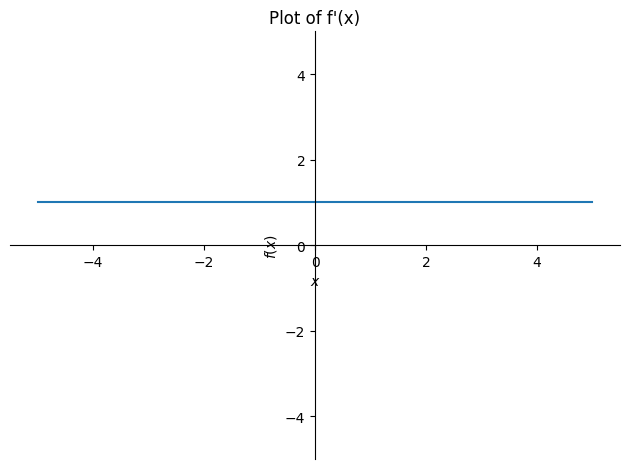

In [30]:
sy.plot(df, (x, -5, 5), ylim=(-5, 5), title='Plot of f\'(x)');

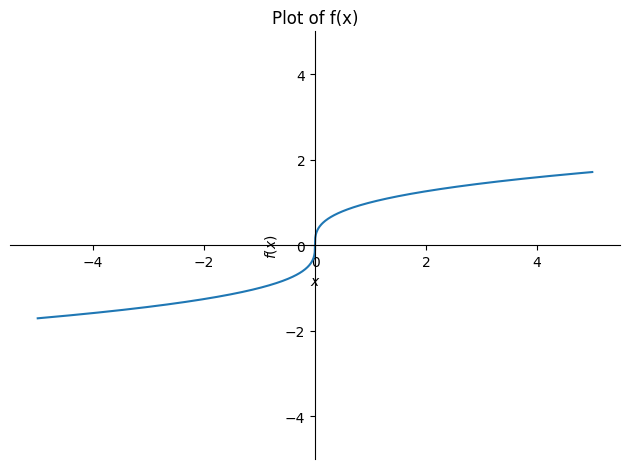

In [31]:
f = sy.real_root(x, 3) # We need to explicitly ask for a real third-root.
sy.plot(f, (x, -5, 5), ylim=(-5, 5), title='Plot of f(x)');

Now let us try to compute the derivative of f. If we naively ask for it we get a non trivial answer:

In [32]:
df = sy.diff(f, x)
display(Math(f"f'(x) = {sy.latex(df)}"))

<IPython.core.display.Math object>

And if you use a limit at 0:

In [33]:
# Compute the limit of f/x as x -> 0
df = sy.limit(f / x, x, 0)
display(Math(f"f'(x) = {sy.latex(df)}"))

<IPython.core.display.Math object>

The reason behind this is that proper plotting and proper computing are sometimes conflicting goals. If you want a simpler and familiar answer for the derivative, use `root`:

In [34]:
f = sy.root(x, 3)
df = sy.diff(f, x)
display(Math(f"f'(x) = {sy.latex(df)}"))

<IPython.core.display.Math object>

# Higher order derivatives

The sympy `diff` function can be used to ask for higher order derivatives of a symbolic function.

In [35]:
from IPython.display import Math, display

# Use sympy to find the derivatives up to order five of f(x) = (x + 2)exp(x)
f = (x + 2) * sy.exp(x)

for i in range(0, 6):
    df = sy.simplify(sy.diff(f, x, i))
    display(Math(f"f^{({i})}(x) = {sy.latex(df)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Note however that in general it is extremely hard to come up with general formulas for higher order derivatives, even for only slighltly more complicated functions:

In [36]:
f = (3 + 2 * x**2) * sy.sin(x)

for i in range(0, 6):
    df = sy.simplify(sy.diff(f, x, i))
    display(Math(f"f^{{({i})}}(x) = {sy.latex(df)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Product rule exploration with generic symbolic functions

Sympy allows us to define *generic* symbolic functions, `f`, `g`, and `h`, without actually describing how to compute them. This can be used to explore the product rule in a purely formal way, that does not depend on the particular choice of functions and therefore shows the **structure** of the result.

In [37]:
f = Function('f')
g = Function('g')
h = Function('h')


We form their product

In [39]:
P = f(x) * g(x) * h(x)

print("Product of these functions:")
display(Math(f"P(x) = {latex(P)}"))


Product of these functions:


<IPython.core.display.Math object>

And we compute the derivative of the product. Can you see the structure and how it generalizes the two-functions case?

In [40]:
dP_dx = diff(P, x)

print("\nDerivative of the product with respect to x:")
display(Math(f"\n(dP/dx) = {latex(dP_dx)}"))


Derivative of the product with respect to x:


<IPython.core.display.Math object>